In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def FFT(x):
    '''
    Helper function to compute 1D-FFT
    '''

    N = len(x)

    if(N == 1):
        return x
    else:
        X_even = FFT(x[::2])
        X_odd = FFT(x[1::2])
        factors = np.exp(-2*1j*np.pi*np.arange(N)/N)

        X = np.concatenate(
            [X_even + factors[:int(N//2)]*X_odd,
             X_even - factors[:int(N//2)]*X_odd]
        )

        return X

In [3]:
def IFFT(x):
    '''
    Helper function to compute 1D-IFFT
    '''

    N = len(x)

    if(N == 1):
        return x
    else:
        X_even = IFFT(x[::2])
        X_odd = IFFT(x[1::2])
        factors = np.exp(2*1j*np.pi*np.arange(N)/N)

        X = np.concatenate(
            [X_even + factors[:int(N/2)]*X_odd,
             X_even - factors[:int(N/2)]*X_odd]
        )

        return X/N

In [4]:
def FFT2d(img:np.ndarray,shift:bool = True):
    '''
    Computes 2D-FFT of given N*N array where N is a power of 2,
    shift centers the FFT if set to true
    '''

    # Check if the FFT needs to be centered
    if(shift):
        mask = np.array([[(-1)**(i+j) for i in range(img.shape[0])] for j in range(img.shape[1])])
        # Multiply each pixel (x,y) with (-1)^(x+y)
        # This centers the spectrum when FFT is computed
        img = np.multiply(mask,img)

    # Calculate Row wise 1D FFT and take transpose to transform columns to rows
    intr = np.array([FFT(row) for row in img]).T # Intermediate Transform

    # Calculate Columwise wise 1D FFT
    fft = np.array([FFT(row) for row in intr]) # Final Transform

    return fft

In [5]:
def IFFT2d(IMG:np.ndarray,shift:bool = True):
    '''
    Computes 2D-IFFT of given N*N array where N is a power of 2,
    shift is set to True if the spectrum is centered
    '''

    # Calculate Row wise 1D IFFT and take transpose to transform columns to rows
    intr = np.array([IFFT(row) for row in IMG]).T # Intermediate Transform

    # Calculate Columwise wise 1D IFFT
    ifft = np.array([IFFT(row) for row in intr]) # Final Transform

    # Check if the FFT is centered
    if(shift):
        mask = np.array([[(-1)**(i+j) for i in range(IMG.shape[0])] for j in range(IMG.shape[1])])
        # Multiply each pixel (x,y) with (-1)^(x+y)
        # This reverses the centering done by FFT function
        ifft = np.multiply(ifft,mask)

    return ifft

In [6]:
import cv2
# img = cv2.imread("cameraman.jpg",cv2.IMREAD_GRAYSCALE )
# img = cv2.imread("dip.tif",cv2.IMREAD_GRAYSCALE )
# img = cv2.imread("jetplane.jpg",cv2.IMREAD_GRAYSCALE )
# img = cv2.imread("lake.jpg",cv2.IMREAD_GRAYSCALE )
# img = cv2.imread("lena_gray_512.jpg",cv2.IMREAD_GRAYSCALE )
# img = cv2.imread("livingroom.jpg",cv2.IMREAD_GRAYSCALE )
# img = cv2.imread("mandril_gray.jpg",cv2.IMREAD_GRAYSCALE )
# img = cv2.imread("pirate.jpg",cv2.IMREAD_GRAYSCALE )
img = cv2.imread("walkbridge.jpg",cv2.IMREAD_GRAYSCALE )

In [7]:
IMG = (FFT2d(img))

In [8]:
mag = np.abs(IMG)
phs = np.angle(IMG)

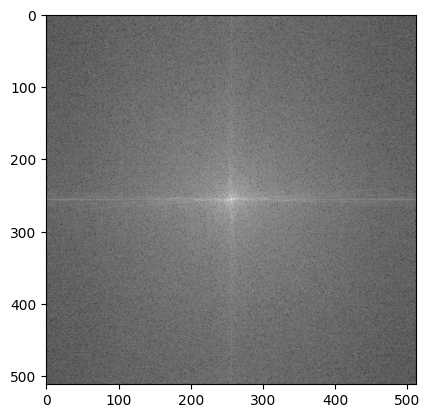

In [9]:
plt.imshow(np.log(mag),cmap = 'gray')

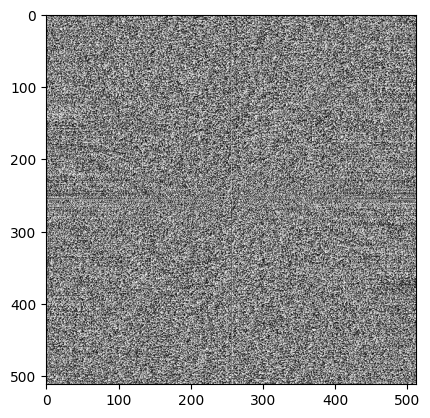

In [10]:
plt.imshow((phs),cmap = 'gray')

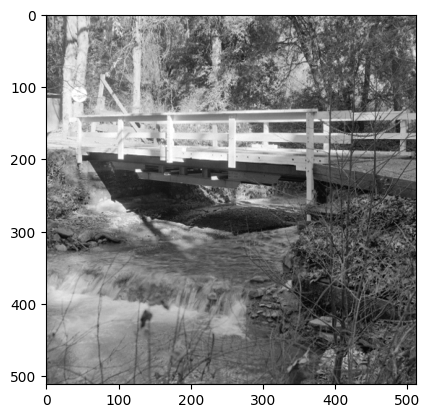

In [11]:
plt.imshow(IFFT2d(IMG).real,cmap = 'gray')

In [12]:
dip = cv2.imread("dip.tif",cv2.IMREAD_GRAYSCALE)

In [13]:
DIP = FFT2d(dip)

In [14]:
DIP_conj = np.conjugate(DIP)

In [15]:
DIP_conj_ifft = IFFT2d(DIP_conj)

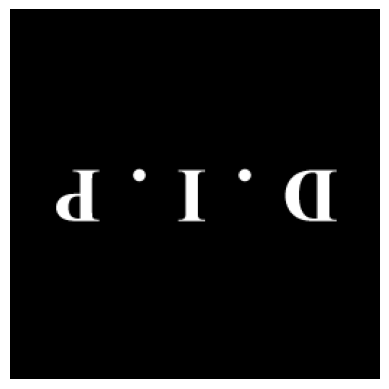

In [16]:
plt.axis("off")
plt.imshow(DIP_conj_ifft.real,cmap = "gray")